# Week 2 Day 5: Decision Tree vs Random Forest

## Today's Goal

Today I will learn how Random Forest improves upon a single Decision Tree.

## Learning Objectives

- Reveiw Decision Tree classification
- Understand Random Forest as an ensemble model
- Compare Logistic Regression, Decision Tree and Random Forest
- Evaluate models using accuracy, precisio, recall and F1-score
- Interpret feature importance

In [3]:
# Step 1: Load the Breast Cancer dataset and split the data

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Target names:", data.target_names)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

X shape: (569, 30)
y shape: (569,)
X_train shape: (455, 30)
X_test shape: (114, 30)
Target names: ['malignant' 'benign']
Train class counts: [170 285]
Test class counts: [42 72]


In [4]:
# Step 2: Train a single Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

tree_train_accuracy = accuracy_score(y_train, y_train_pred_tree)
tree_test_accuracy = accuracy_score(y_test, y_test_pred_tree)

print("Decision Tree train accuracy:", tree_train_accuracy)
print("Decision Tree test accuracy:", tree_test_accuracy)

print("Decision Tree test precision:", precision_score(y_test, y_test_pred_tree))
print("Decision Tree test recall:", recall_score(y_test, y_test_pred_tree))
print("Decision Tree test F1:", f1_score(y_test, y_test_pred_tree))

Decision Tree train accuracy: 1.0
Decision Tree test accuracy: 0.9122807017543859
Decision Tree test precision: 0.9558823529411765
Decision Tree test recall: 0.9027777777777778
Decision Tree test F1: 0.9285714285714286


In [6]:
# Step 3: Train a Random Forest

from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_train_pred_forest = forest_model.predict(X_train)
y_test_pred_forest = forest_model.predict(X_test)

forest_train_accuracy = accuracy_score(y_train, y_train_pred_forest)
forest_test_accuracy = accuracy_score(y_test, y_test_pred_forest)

print("Random Forest train accuracy:", forest_train_accuracy)
print("Random Forest test accuracy:", forest_test_accuracy)

print("Random Forest test precision:", precision_score(y_test, y_test_pred_forest))
print("Random Forest test recall:", recall_score(y_test, y_test_pred_forest))
print("Random Forest test F1:", f1_score(y_test, y_test_pred_forest))

Random Forest train accuracy: 1.0
Random Forest test accuracy: 0.956140350877193
Random Forest test precision: 0.958904109589041
Random Forest test recall: 0.9722222222222222
Random Forest test F1: 0.9655172413793104


In [8]:
# Step 4: Compare Logistic Regression, Decision Tree and Random Forest

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=10000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decicsion Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517


In [9]:
# Step 5: Random Forest feature importance

importance_df = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


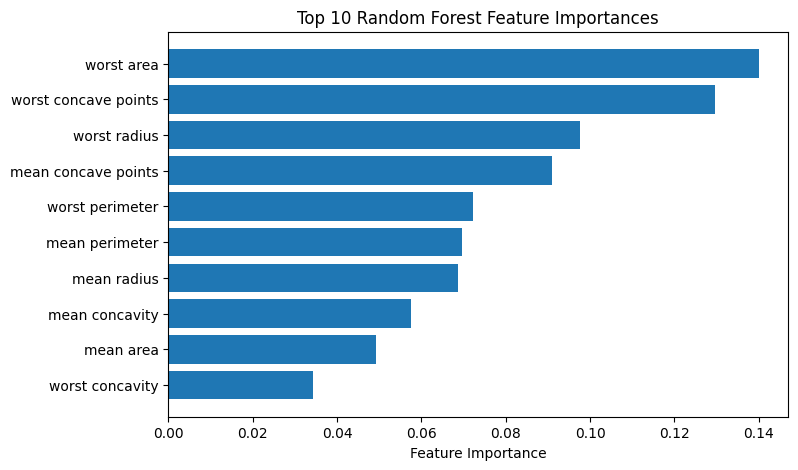

In [10]:
# Visualize top 10 feature importances

import matplotlib.pyplot as plt

top_10 = importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_10["Feature"], top_10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

In [ ]:
# Reflection

## 1. What did I learn today?
I learnt the difference between Random Forest and Logistic Regression
## 2. Why can a single Decision Tree easily overfit?
Because a single Decision Tree is easily affeted by noise
## 3. Why can Random Forest perform better than a single Decision Tree?
Because Random Forest set lots of Decision Tree to lessen overfitting
## 4. In today's comparison, which model performed best? Why should I not conclude that this model is always the best?
Logistic Regression performed better in this dataset. Because today's result just represents the good performance in this comprasion.
## 5. What does Random Forest feature importance mean?
Feature importance is the importance of features and it decides the order of decision.
## 6. Why does feature importance not mean medical causality?
Because feature importance is the importance in the pocess of Decision Tree 
## 7. What mistakes or misunderstandings did I have today?
No